### 第一次作业 学习python基础使用并完成数据拟合


#### 数据加载与散点图绘制

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import altair as alt

#alt.theme.enable('dark')

In [93]:
train_data = pd.read_csv('Data4Regression - Training Data.csv', usecols=['x', 'y_complex']) 
test_data = pd.read_csv('Data4Regression - Test Data.csv', usecols=['x_new', 'y_new_complex'])

# 打印前两行数据
print(train_data.head(2))
print(test_data.head(2))

         x  y_complex
0  0.00000  -0.751643
1  0.10101  -0.926640
     x_new  y_new_complex
0  0.00000      -1.071179
1  0.10101       0.171103


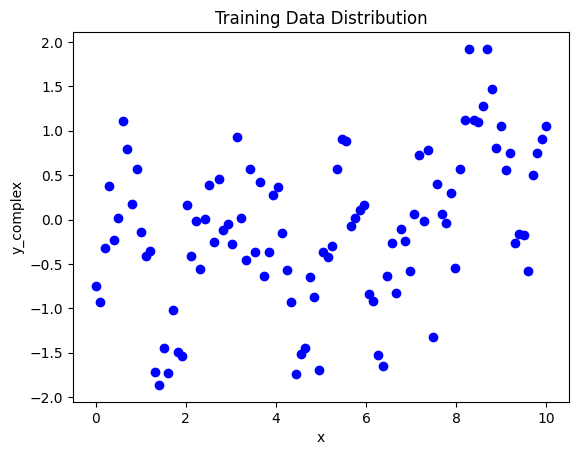

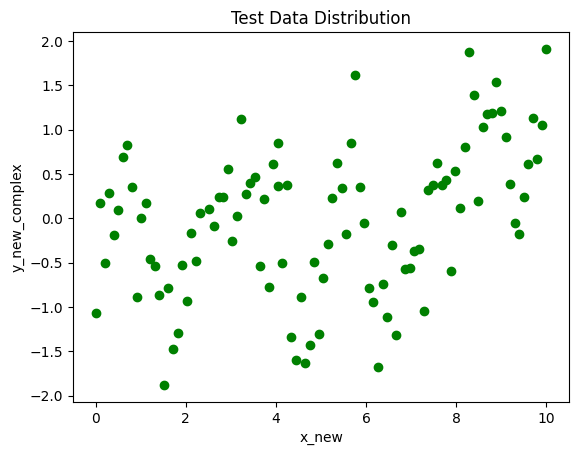

"chart = alt.Chart(train_data).mark_circle(size=60).encode(\n    x='x',\n    y='y_complex',\n    tooltip=['x', 'y_complex']  # 鼠标悬停就能看到具体数值\n).properties(\n    title='Training Data Distribution (Altair Version)',\n    width=600,\n    height=400\n)\nchart.show()\n"

In [94]:
x_train = train_data['x'].values
y_train = train_data['y_complex'].values
x_test = test_data['x_new'].values
y_test = test_data['y_new_complex'].values

##这里尝试了一下matplotlib和altair两种可视化工具
plt.scatter(x_train, y_train, label='Training Data',color='blue')
plt.xlabel('x')
plt.ylabel('y_complex')
plt.title('Training Data Distribution')
# 在 show 之前保存，format='svg' 会生成高质量矢量图
plt.savefig('Training Data Distribution', format='svg')
plt.show()

plt.scatter(x_test, y_test, label='Test Data', color='green')
plt.xlabel('x_new')
plt.ylabel('y_new_complex')
plt.title('Test Data Distribution')
plt.show()

##Error loading script: Script error for "vega-embed" https://requirejs.org/docs/errors.html#scripterror
'''chart = alt.Chart(train_data).mark_circle(size=60).encode(
    x='x',
    y='y_complex',
    tooltip=['x', 'y_complex']  # 鼠标悬停就能看到具体数值
).properties(
    title='Training Data Distribution (Altair Version)',
    width=600,
    height=400
)
chart.show()
'''

#### 最小二乘法(Ordinary Least Squares, OLS)

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_data = pd.read_csv('Data4Regression - Training Data.csv', usecols=['x', 'y_complex']) 
test_data = pd.read_csv('Data4Regression - Test Data.csv', usecols=['x_new', 'y_new_complex'])

x_train = train_data['x'].values
y_train = train_data['y_complex'].values
x_test = test_data['x_new'].values
y_test = test_data['y_new_complex'].values


基本的代数求解：$y = wx + b$
$$w = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$
$$\bar{y} = w\bar{x} + b$$

In [96]:
# 1.计算均值
x_mean = np.mean(x_train)
y_mean = np.mean(y_train)

# 2.计算w
up = np.sum((x_train - x_mean) * (y_train - y_mean))
down = np.sum((x_train - x_mean)**2)
w_1 = up / down

# 3.截距b
b_1 = y_mean - w_1 * x_mean

print(f"方法1结果: b = {b_1:.4f}, w = {w_1:.4f}")

方法1结果: b = -0.6487, w = 0.1089


机器学习标准的数学形式：$y = X\theta$
$$ \theta = (X^T  X)^{-1} X^T  y $$
$$y = [1, x] \cdot \begin{bmatrix} b \\ w \end{bmatrix}$$

In [97]:
#标准做法：给训练数据和测试x左边添加1，利用矩阵乘法
X_b_train = np.c_[np.ones((len(x_train), 1)), x_train] 
X_b_test = np.c_[np.ones((len(x_test), 1)), x_test]


theta = np.linalg.inv(X_b_train.T.dot(X_b_train)).dot(X_b_train.T).dot(y_train)

b_2 = theta[0] # 截距 b
w_2 = theta[1]     # 斜率 w

print(f"方法2结果: b = {b_2:.4f}, w = {w_2:.4f}")

方法2结果: b = -0.6487, w = 0.1089


In [98]:
RMSE_1_test = np.sqrt(np.mean((y_test - (b_1 + w_1 * x_test))**2))
print(f"方法1在测试集上的RMSE: {RMSE_1_test:.4f}") 

RMSE_2_test = np.sqrt(np.mean((y_test - (b_2 + w_2 * x_test))**2))
print(f"方法2在测试集上的RMSE: {RMSE_2_test:.4f}") 

RMSE_1_train = np.sqrt(np.mean((y_train - (b_1 + w_1 * x_train))**2))
print(f"方法1在训练集上的RMSE: {RMSE_1_train:.4f}") 

RMSE_2_train = np.sqrt(np.mean((y_train - (b_2 + w_2 * x_train))**2))
print(f"方法2在训练集上的RMSE: {RMSE_2_train:.4f}") 

方法1在测试集上的RMSE: 0.7714
方法2在测试集上的RMSE: 0.7714
方法1在训练集上的RMSE: 0.7832
方法2在训练集上的RMSE: 0.7832


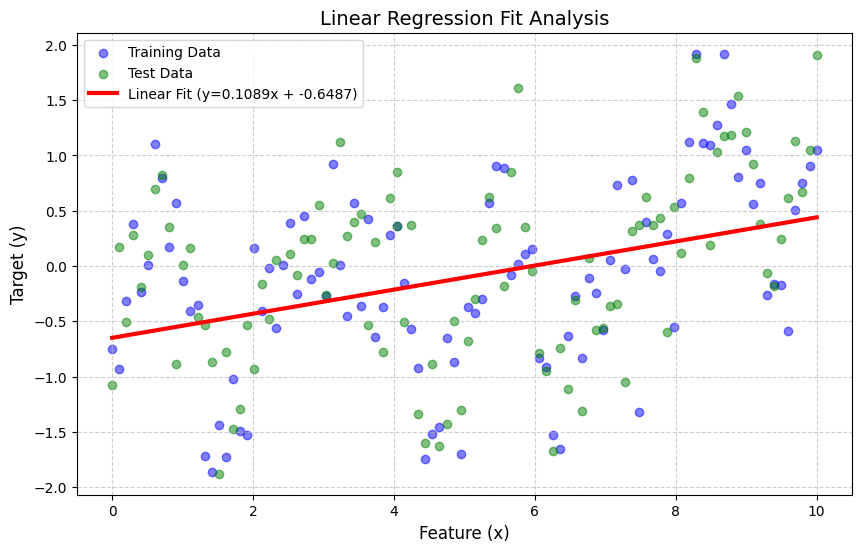

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.5, label='Training Data')#alpha点的透明度
plt.scatter(x_test, y_test, color='green', alpha=0.5, label='Test Data')

x_range = np.array([x_train.min(), x_train.max()])
y_range = b_2 + w_2 * x_range

plt.plot(x_range, y_range, color='red', linewidth=3, label=f'Linear Fit (y={w_2:.4f}x + {b_2:.4f})')

plt.title("Linear Regression Fit Analysis", fontsize=14)
plt.xlabel("Feature (x)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend() # 显示图例
plt.grid(True, linestyle='--', alpha=0.6) # 添加网格线

plt.show()

#### 梯度下降算法(Gradient Descent, GD)

梯度下降的权重更新公式如下：
$$w = w - \alpha \frac{1}{m} X^T (Xw - y)$$

In [100]:
alpha = 0.05  #学习率
iterations = 1000  #迭代次数
w_gd = np.random.randn(2, 1) 
m = len(y_train)
loss = []

# 迭代训练
for i in range(iterations):
    y_pre = X_b_train.dot(w_gd)
    
    # reshape(-1, 1)y转置
    errors = y_pre - y_train.reshape(-1, 1)
    
    gradient = (1/m) * X_b_train.T.dot(errors)
    w_gd = w_gd - alpha * gradient
    
    # 记录当前的 MSE (均方误差)
    cost = np.mean(errors**2)
    loss.append(cost)

print(f"截距 b: {w_gd[0][0]:.4f}")
print(f"斜率 w: {w_gd[1][0]:.4f}")

截距 b: -0.6487
斜率 w: 0.1089


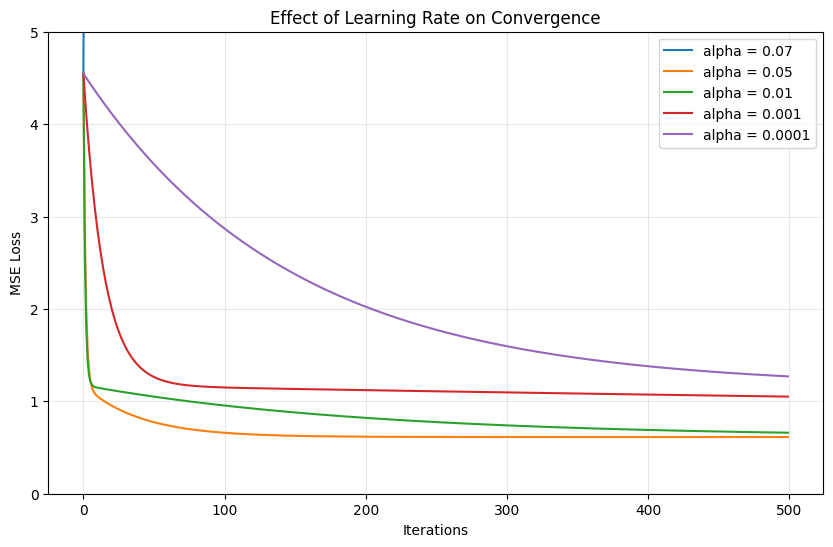

In [101]:
#测试不同学习率和迭代次数
def gradient_descent_experiment(X, y, alpha, iterations):
    np.random.seed(20) #固定随机种子
    w_gd = np.random.randn(2, 1)
    m = len(y)
    loss = []
    
    y_mat = y.reshape(-1, 1)

    for i in range(iterations):
        prediction = X.dot(w_gd)
        errors = prediction - y_mat

        gradient = (1/m) * X.T.dot(errors)
        w_gd = w_gd - alpha * gradient
       
        cost = np.mean(errors**2)
        loss.append(cost)
        
    return w_gd, loss
#实验表明，当alpha取0.08，报warning:overflow encountered in square cost = np.mean(errors**2)
alphas = [0.07,0.05,0.01,0.001,0.0001]
i = 500

plt.figure(figsize=(10, 6))

for a in alphas:
    w_gd, loss = gradient_descent_experiment(X_b_train, y_train, a, i)
    plt.plot(range(i), loss, label=f'alpha = {a}')

plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.ylim(0, 5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

选择alpha=0.5重新跑了一遍，最后收敛到的b,w和LOS结果一致

### 牛顿法线性拟合：

牛顿法不需要设置alpha，步长求梯度自动下降：
$$\theta = \theta - H^{-1} \nabla J(\theta)$$
其中，
$$\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)$$
$$H = \frac{1}{m} X^T X$$

对于线性回归 $$\theta = \theta - ( \frac{1}{m} X^T X )^{-1} \cdot ( \frac{1}{m} X^T (X\theta - y) )$$化简掉 $\frac{1}{m}$ 后：$$\theta = \theta - (X^T X)^{-1} X^T (X\theta - y)$$ 
- 如果从 $\theta = 0$ 开始迭代，牛顿法算出来的第一步结果就是：$$\theta = (X^T X)^{-1} X^T y$$

In [102]:
m = len(y_train)
X = X_b_train
y = y_train.reshape(-1, 1)

gradient = (1/m) * X.T.dot(X.dot(w_gd) - y)

Hessian = (1/m) * X.T.dot(X)

w_newton = w_gd - np.linalg.inv(Hessian).dot(gradient)

print(f"截距 b: {w_newton[0][0]:.4f}")
print(f"斜率 w: {w_newton[1][0]:.4f}")

截距 b: -0.6487
斜率 w: 0.1089


第1问：

最小二乘法的方法 1（初中数学的基本代数求解）与方法 2（矩阵法）得到了相同的模型参数，验证了计算的准确性。OLS/GD/Newton结果一致，GD需要设计学习率小于0.08并多次迭代，OLS、Newton不需要，对于线性回归问题更新一次就求解出了正确答案。参数拟合结果：b = -0.6487, w = 0.1089。训练集 RMSE 为 0.7832，测试集 RMSE 为 0.7714。

虽然模型在测试集上的表现与训练集接近，但整体误差值较高。通过绘图观察，__该线性模型无法良好拟合__。

### 非线性拟合

非线性拟合，采用基于高斯过程回归的非参数拟合代码。（Gemini辅助完成）

**模型训练与优化**
- 设置`n_restarts_optimizer=10`，通过多次随机初始化寻找最优参数
- 自动学习内核参数（如长度尺度、噪声水平等）

**预测与不确定性估计**
- 在[0,10]区间生成密集的预测点
- 同时返回预测均值y_pred和标准差sigma
- 利用标准差构建95%置信区间（1.96倍标准差）

**技术优势**
- **非参数特性**：无需预设函数形式，由数据驱动拟合
- **不确定性量化**：不仅预测值，还给出预测的可信度
- **自动噪声估计**：通过WhiteKernel学习数据噪声水平
- **抗过拟合**：概率模型天生具有正则化效果


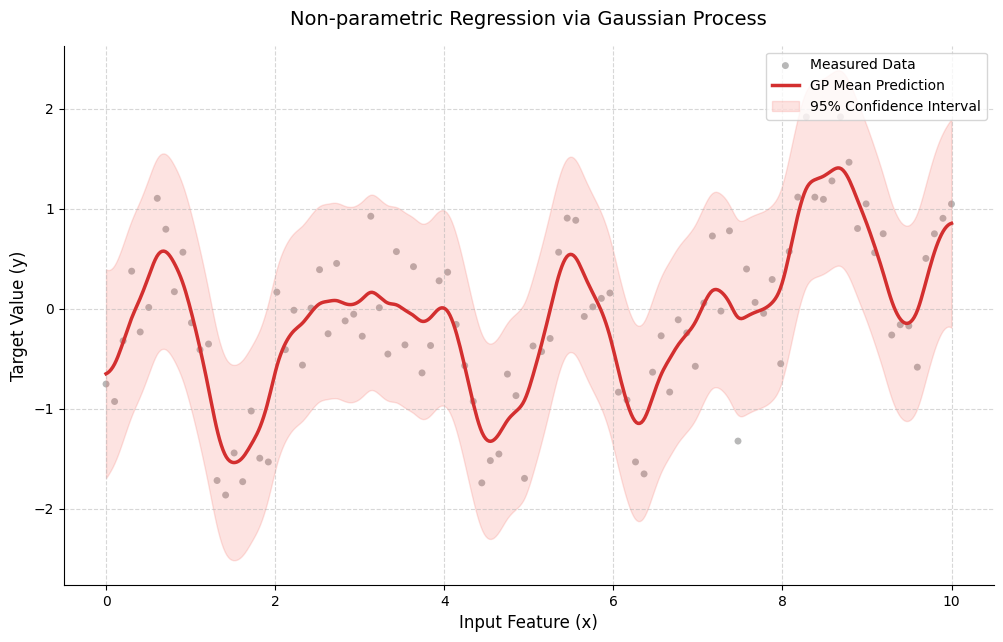

模型自动识别的噪声水平: 0.1948


In [103]:
from turtle import color

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# 1. 数据准备
train_data = pd.read_csv('Data4Regression - Training Data.csv')[['x', 'y_complex']].dropna()
X = train_data['x'].values.reshape(-1, 1)
y = train_data['y_complex'].values

# 2. 配置高斯过程内核
# ConstantKernel: 调整整体振幅
# Matern: 这是一个非常全能的核，比 RBF 更适合这种带有细微抖动的数据
# WhiteKernel: 自动估计数据中的噪声水平，防止曲线过度拟合噪声点
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.1)

# 3. 拟合模型
# n_restarts_optimizer=10 表示多次尝试寻找全局最优参数，确保不卡在局部
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr.fit(X, y)

# 4. 预测与置信区间计算
x_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_pred, sigma = gpr.predict(x_plot, return_std=True)

# 5. 绘图
plt.figure(figsize=(12, 7), dpi=100)

# 绘制原始数据点
plt.scatter(X, y, color='#4F4F4F', alpha=0.4, s=25, label='Measured Data', edgecolors='none')

# 绘制均值预测线红线
plt.plot(x_plot, y_pred, color='#D32F2F', lw=2.5, label='GP Mean Prediction')

# 绘制 95% 置信区间
# y_pred ± 1.96 * sigma 对应正态分布下的 95% 概率区间
plt.fill_between(x_plot.flatten(), 
                 y_pred - 1.96 * sigma, 
                 y_pred + 1.96 * sigma, 
                 color='#F44336', alpha=0.15, label='95% Confidence Interval')

plt.title('Non-parametric Regression via Gaussian Process', fontsize=14, pad=15)
plt.xlabel('Input Feature (x)', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

print(f"模型自动识别的噪声水平: {gpr.kernel_.get_params()['k2__noise_level']:.4f}")

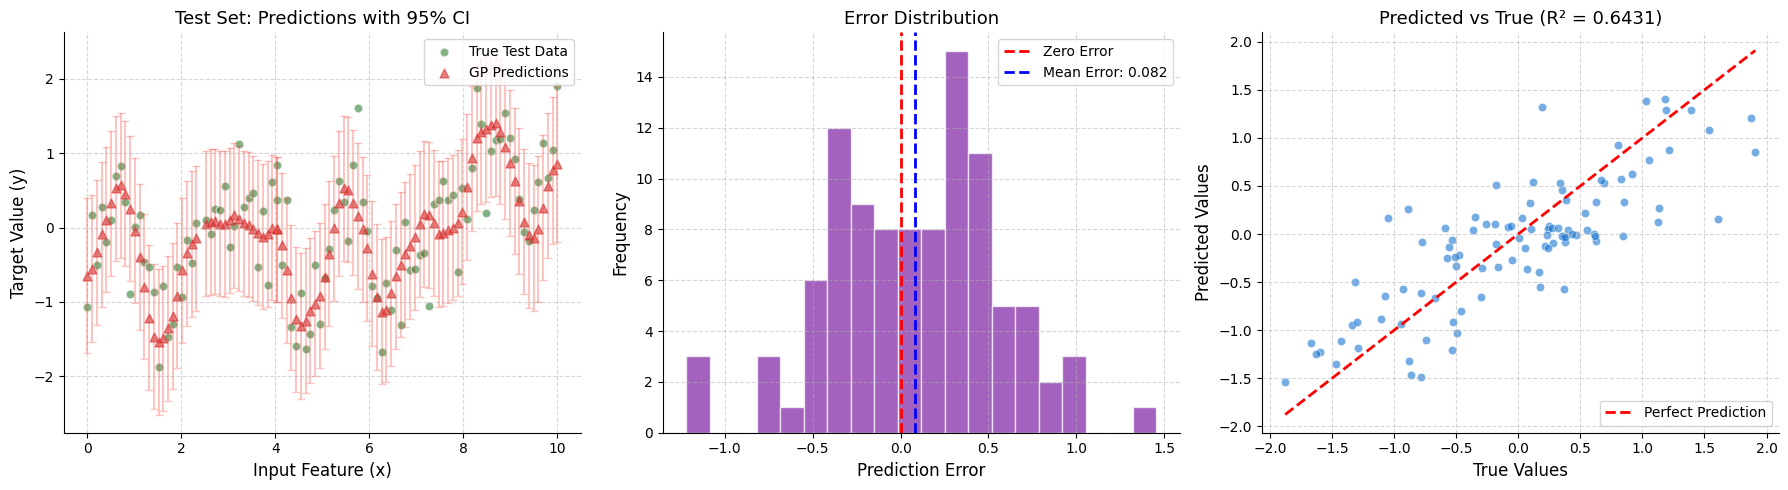

Mean Squared Error (MSE):      0.244944
Root Mean Squared Error (RMSE): 0.494918
Mean Absolute Error (MAE):      0.406489
R² Score:                       0.643056
95% CI Coverage Rate:           94.0%
Average Prediction Std:         0.4992


In [104]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 加载测试数据
test_data = pd.read_csv('Data4Regression - Test Data.csv')[['x_new', 'y_new_complex']].dropna()
X_test = test_data['x_new'].values.reshape(-1, 1)
y_test = test_data['y_new_complex'].values

# 2. 测试集预测
y_test_pred, sigma_test = gpr.predict(X_test, return_std=True)

# 3. 计算测试集评估指标
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# 计算测试点在95%置信区间内的比例
within_95ci = np.abs(y_test - y_test_pred) <= 1.96 * sigma_test
coverage_rate = np.mean(within_95ci) * 100

# 4. 创建测试集可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# 子图1：测试集预测对比
ax1 = axes[0]
ax1.scatter(X_test, y_test, color='#2E7D32', alpha=0.6, s=40, label='True Test Data', edgecolors='white')
ax1.scatter(X_test, y_test_pred, color='#D32F2F', alpha=0.6, s=40, marker='^', label='GP Predictions')
ax1.errorbar(X_test.flatten(), y_test_pred, yerr=1.96*sigma_test, 
             fmt='none', ecolor='#F44336', alpha=0.3, capsize=3)
ax1.set_xlabel('Input Feature (x)', fontsize=12)
ax1.set_ylabel('Target Value (y)', fontsize=12)
ax1.set_title('Test Set: Predictions with 95% CI', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2：预测误差分布
ax2 = axes[1]
errors = y_test - y_test_pred
ax2.hist(errors, bins=20, color='#7B1FA2', alpha=0.7, edgecolor='white')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.axvline(x=np.mean(errors), color='blue', linestyle='--', linewidth=2, 
            label=f'Mean Error: {np.mean(errors):.3f}')
ax2.set_xlabel('Prediction Error', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Error Distribution', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3：预测值vs真实值
ax3 = axes[2]
ax3.scatter(y_test, y_test_pred, alpha=0.6, color='#1976D2', edgecolors='white', linewidth=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('True Values', fontsize=12)
ax3.set_ylabel('Predicted Values', fontsize=12)
ax3.set_title(f'Predicted vs True (R² = {r2:.4f})', fontsize=13)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower right')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 5. 打印评估结果
print(f"Mean Squared Error (MSE):      {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.6f}")
print(f"Mean Absolute Error (MAE):      {mae:.6f}")
print(f"R² Score:                       {r2:.6f}")
print(f"95% CI Coverage Rate:           {coverage_rate:.1f}%")
print(f"Average Prediction Std:         {np.mean(sigma_test):.4f}")

第2问：

（1）精度显著提升：相比于第一问线性回归的测试集 RMSE (0.7714)，高斯过程回归的 RMSE 降低至 0.4949，误差降幅约 36\%。

（2）拟合质量评估：$R^2$ 分数为 0.6431，模型已经提取了绝大部分有效的信号。94.0% 的置信区间覆盖率与理论值 95% 极其接近。

（3）高斯过程回归解决了线性模型的欠拟合问题。不仅提供了一条平滑且贴合数据趋势的拟合曲线，还通过概率分布的形式给出了预测的可靠性范围。